In [ ]:
# @title 1. Cleaning data and scoring
import os
import argparse
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

# Core model imports
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

# --- CONSTANTS FOR ONLINE LOADING ---
# NOTE: Replace 'USER_ADAPTER_REPO_ID' with the actual Hugging Face ID for your ImBD adapter
IMBD_ADAPTER_HUB_ID = "xyzhu1225/ImBD-inference"
GPT_NEO_125M_HUB_ID = "EleutherAI/gpt-neo-125M"
GPT_NEO_2_7B_HUB_ID = "EleutherAI/gpt-neo-2.7B"
# ------------------------------------

# ------------------------------------------------------
# Device setup
# ------------------------------------------------------
def setup_device():
    # Check if CUDA (GPU) is available and return the appropriate device
    if torch.cuda.is_available():
        print("✅ Using GPU (CUDA)")
        return torch.device("cuda")
    # Removed MPS check for brevity and focus on the T4 GPU environment
    else:
        # Fallback to CPU if no GPU is found
        print("⚠️ Using CPU (no GPU backend found)")
        return torch.device("cpu")

# ------------------------------------------------------
# Data reading and cleaning
# ------------------------------------------------------
def read_f1000(path: str) -> pd.DataFrame:
    # Read the input file (either Excel or CSV) into a pandas DataFrame
    df = pd.read_excel(path) if path.lower().endswith((".xls", ".xlsx")) else pd.read_csv(path)
    # Define the columns to keep from the DataFrame
    keep = [c for c in [
        "doi", "title", "abstract", "subject", "publication_year",
        "reviewer_recommendation", "article_type"
    ] if c in df.columns]
    # Filter the DataFrame to keep only the specified columns and create a copy
    df = df[keep].copy()
    # Convert 'publication_year' to numeric, coercing errors to NaN, then to nullable integer type
    if "publication_year" in df:
        df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce").astype("Int64")
    return df

def clean_text(x: str, max_len: int = 1500) -> str:
    # Handle non-string inputs by returning an empty string
    if not isinstance(x, str):
        return " "
    # Remove leading/trailing whitespace and normalize internal spaces
    x = " ".join(x.strip().split())
    # Truncate text to max_len if it exceeds the limit, otherwise return as is
    return x[:max_len] if x else " "

# ------------------------------------------------------
# Token-level scoring utilities
# ------------------------------------------------------
@torch.no_grad()
def get_token_logprobs_and_logits(texts, tokenizer, model, device, max_tokens=1024):
    # Tokenize input texts, returning PyTorch tensors, padding, and truncating to max_tokens
    enc = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=max_tokens)
    # Move input IDs and attention mask to the specified device
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    # Get model outputs (logits)
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits
    # Calculate log probabilities from logits
    logprobs = torch.log_softmax(logits, dim=-1)

    # Get observed token IDs (shifted by one for prediction)
    obs_token_ids = input_ids[:, 1:]
    # Get attention mask for observed tokens
    obs_mask = attention_mask[:, 1:]
    # Gather predicted log probabilities for the observed tokens
    pred_logprobs_for_obs = logprobs[:, :-1, :].gather(-1, obs_token_ids.unsqueeze(-1)).squeeze(-1)
    # Apply the attention mask to log probabilities
    pred_logprobs_for_obs = pred_logprobs_for_obs * obs_mask
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "logprobs": logprobs,
        "pred_logprobs_for_obs": pred_logprobs_for_obs
    }

def average_log_likelihood(logprob_obs, mask):
    # Calculate the denominator for averaging (sum of mask, clamped to min 1 to avoid division by zero)
    denom = mask.sum(dim=1).clamp(min=1)
    # Compute average log likelihood
    return (logprob_obs.sum(dim=1) / denom).cpu().numpy()

def average_log_rank(logits, input_ids, attention_mask):
    # Get logits (excluding the last token) and move to CPU
    logits_next = logits[:, :-1, :].cpu()
    # Get true input IDs (excluding the first token) and move to CPU
    true_ids = input_ids[:, 1:].cpu()
    # Get attention mask (excluding the first token) and move to CPU
    mask = attention_mask[:, 1:].cpu()

    # Sort logits to find ranks
    sorted_indices = torch.argsort(logits_next, dim=-1, descending=True)
    # Expand true IDs for comparison
    true_ids_exp = true_ids.unsqueeze(-1)
    # Find matches between sorted indices and true IDs
    matches = (sorted_indices == true_ids_exp).nonzero(as_tuple=False)
    # Initialize ranks tensor
    ranks = torch.zeros_like(true_ids, dtype=torch.long)

    # Populate ranks where matches are found
    if matches.numel() > 0:
        ranks[matches[:, 0], matches[:, 1]] = matches[:, 2] + 1

    # Clamp ranks to a minimum of 1 and calculate log ranks
    ranks = ranks.clamp(min=1)
    log_ranks = torch.log(ranks.float())
    # Calculate the denominator for averaging
    denom = mask.sum(dim=1).clamp(min=1)
    # Compute average log rank
    return ((log_ranks * mask).sum(dim=1) / denom).numpy()

# ------------------------------------------------------
# Scoring functions (FDG, LRR, ImBD)
# ------------------------------------------------------
def score_fast_detectgpt_curvature(batch_texts, tokenizer, model, device, max_tokens=1024):
    # Get token log probabilities and logits from the model
    out = get_token_logprobs_and_logits(batch_texts, tokenizer, model, device, max_tokens)
    # Extract logprobs, observed logprobs, and mask
    logprobs = out["logprobs"][:, :-1, :]
    obs_lp = out["pred_logprobs_for_obs"]
    mask = out["attention_mask"][:, 1:]

    # Calculate token probabilities and entropy
    p = torch.exp(logprobs)
    token_entropy = -(p * logprobs).sum(dim=-1)
    # Calculate mean (mu) and variance (var) for the curvature score
    mu = -token_entropy
    var = ((p * (logprobs ** 2)).sum(dim=-1) - mu**2).clamp(min=1e-12)
    sigma = torch.sqrt(var)
    # Compute the z-score for curvature
    z = ((obs_lp - mu) / sigma) * mask
    # Calculate the denominator for averaging
    denom = mask.sum(dim=1).clamp(min=1)
    # Return the averaged z-score
    return (z.sum(dim=1) / denom).cpu().numpy()

def score_LRR(batch_texts, tokenizer, model, device, max_tokens=1024):
    # Get token log probabilities and logits
    out = get_token_logprobs_and_logits(batch_texts, tokenizer, model, device, max_tokens)
    # Extract mask
    mask = out["attention_mask"][:, 1:]
    # Calculate average log likelihood and average log rank
    avg_ll = average_log_likelihood(out["pred_logprobs_for_obs"], mask)
    avg_log_rank = average_log_rank(out["logprobs"], out["input_ids"], out["attention_mask"])
    # Compute LRR score
    lrr = -avg_ll / (avg_log_rank + 1e-8)
    return lrr, avg_ll, avg_log_rank

def score_imbd_single(batch_texts, tokenizer, model, device, max_tokens=1024):
    """Runs ImBD model directly (self-contained inference model)."""
    # Tokenize input texts
    enc = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=max_tokens)
    # Move input IDs and attention mask to the device
    input_ids = enc["input_ids"].to(device)
    attn = enc["attention_mask"].to(device)

    with torch.no_grad():
        # Get model outputs (logits)
        outputs = model(input_ids=input_ids, attention_mask=attn)

    logits = outputs.logits
    # Calculate log probabilities
    logprobs = torch.log_softmax(logits, dim=-1)

    # Extract observed token IDs and mask
    obs_ids = input_ids[:, 1:]
    mask = attn[:, 1:]
    # Gather predicted log probabilities for observed tokens
    pred_lp = logprobs[:, :-1, :].gather(-1, obs_ids.unsqueeze(-1)).squeeze(-1)

    # Calculate probabilities, mean (mu), and variance (var)
    p = torch.exp(logprobs[:, :-1, :])
    mu = (p * logprobs[:, :-1, :]).sum(dim=-1)
    var = (p * (logprobs[:, :-1, :] - mu.unsqueeze(-1)) ** 2).sum(dim=-1)
    sigma = torch.sqrt(var.clamp(min=1e-12))

    # Compute z-score
    z = (pred_lp - mu) / sigma
    z = z * mask
    # Calculate the denominator for averaging
    denom = mask.sum(dim=1).clamp(min=1)
    # Return the averaged z-score
    return (z.sum(dim=1) / denom).cpu().numpy()

# ------------------------------------------------------
# NEW STAGE 1 SCORING FUNCTION
# ------------------------------------------------------
def score_lrr_fdg(df, base_tokenizer, base_model, device, batch_size, max_tokens):
    print(f"\nSTAGE 1: Scoring LRR/FDG with GPT-Neo 125M (Batch size: {batch_size})")
    # Extract abstracts from DataFrame, handling missing values
    texts = df["abstract"].fillna("").tolist()
    lrr_scores, fdg_scores, avg_lls, avg_lrs = [], [], [], []

    # Iterate through texts in batches for scoring
    for i in tqdm(range(0, len(texts), batch_size), desc="LRR/FDG Scoring"):
        batch = texts[i:i+batch_size]
        # Score LRR and FDG for the current batch
        lrr, avg_ll, avg_lr = score_LRR(batch, base_tokenizer, base_model, device, max_tokens)
        fdg = score_fast_detectgpt_curvature(batch, base_tokenizer, base_model, device, max_tokens)
        # Extend lists with batch scores
        lrr_scores.extend(lrr)
        avg_lls.extend(avg_ll)
        avg_lrs.extend(avg_lr)
        fdg_scores.extend(fdg)

    # Add computed scores as new columns to the DataFrame
    df["score_lrr"] = lrr_scores
    df["score_avg_ll"] = avg_lls
    df["score_avg_logrank"] = avg_lrs
    df["score_fast_detectgpt"] = fdg_scores
    return df

# ------------------------------------------------------
# NEW STAGE 2 SCORING FUNCTION
# ------------------------------------------------------
def score_imbd(df, imbd_tokenizer, imbd_model, device, batch_size, max_tokens):
    print(f"\nSTAGE 2: Scoring ImBD with GPT-Neo 2.7B Adapter (Batch size: {batch_size})")
    # Extract abstracts from DataFrame, handling missing values
    texts = df["abstract"].fillna("").tolist()
    imbd_scores = []

    # Iterate through texts in batches for scoring
    for i in tqdm(range(0, len(texts), batch_size), desc="ImBD Scoring"):
        batch = texts[i:i+batch_size]
        # Score ImBD for the current batch
        imbd = score_imbd_single(batch, imbd_tokenizer, imbd_model, device, max_tokens)
        # Extend list with batch scores
        imbd_scores.extend(imbd)

    # Add computed ImBD scores as a new column to the DataFrame
    df["score_imbd"] = imbd_scores
    return df

# ------------------------------------------------------
# Main pipeline (FOR SEQUENTIAL LOGIC)
# ------------------------------------------------------
def pipeline(input, base_model_name, imbd_model_dir,
             batch_size=2, max_tokens=128, max_chars=3000, flag_quantile=0.30, outdir="outputs"):

    # Setup computation device (CPU or GPU)
    device = setup_device()

    # Read the input data and clean the abstract text
    full = read_f1000(input)
    full["abstract"] = full["abstract"].map(lambda x: clean_text(x, max_len=max_chars))
    print(f"Total rows before deduplication: {len(full)}")

    # Drop duplicate abstracts to process unique entries only
    unique = full.drop_duplicates(subset=["abstract"], keep="first").reset_index(drop=True)
    print(f"Unique abstracts: {len(unique)}")

    # Model loading arguments for efficient memory usage (FP16 on CUDA)
    model_load_args = {
        "torch_dtype": torch.float16 if device.type == 'cuda' else None,
        "low_cpu_mem_usage": True
    }

    # --- STAGE 1: LRR/FDG Scoring ---

    # 1. Load Model 1 (GPT-Neo 125M) and its tokenizer
    base_tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    # Set pad token if not already defined
    if base_tokenizer.pad_token is None:
        base_tokenizer.pad_token = base_tokenizer.eos_token
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name, **model_load_args
    ).to(device).eval()

    # 2. Score unique abstracts with Model 1
    unique = score_lrr_fdg(unique, base_tokenizer, base_model, device, batch_size, max_tokens)

    # 3. CRITICAL: Unload Model 1 and clear VRAM to free up resources for the next model
    print("Unloading GPT-Neo 125M...")
    del base_model
    del base_tokenizer
    torch.cuda.empty_cache()

    # --- STAGE 2: ImBD Scoring ---

    # 1. Load Model 2 Base (GPT-Neo 2.7B)
    print("\nLoading ImBD base model (GPT-Neo 2.7B)")
    base_27b = AutoModelForCausalLM.from_pretrained(GPT_NEO_2_7B_HUB_ID, **model_load_args)

    # 2. Attach the ImBD adapter (PEFT model) to the base model
    print(f"Loading ImBD adapter from Hub: {imbd_model_dir}")
    imbd_model = PeftModel.from_pretrained(
        base_27b,
        imbd_model_dir,
        **model_load_args
    ).to(device).eval()

    # 3. Load Tokenizer for ImBD (from the adapter directory)
    imbd_tokenizer = AutoTokenizer.from_pretrained(imbd_model_dir)
    # Set pad token if not already defined
    if imbd_tokenizer.pad_token is None:
        imbd_tokenizer.pad_token = imbd_tokenizer.eos_token

    # 4. Score unique abstracts with Model 2
    unique = score_imbd(unique, imbd_tokenizer, imbd_model, device, batch_size, max_tokens)

    # 5. CRITICAL: Unload Model 2 and clear VRAM
    print("Unloading GPT-Neo 2.7B...")
    del imbd_model
    del base_27b
    del imbd_tokenizer
    torch.cuda.empty_cache()

    # 4. Flagging: Identify abstracts that score above a certain quantile for each detector
    q = flag_quantile
    unique["flag_llm_lrr"] = (unique["score_lrr"] >= unique["score_lrr"].quantile(1-q)).astype(int)
    unique["flag_llm_fdg"] = (unique["score_fast_detectgpt"] >= unique["score_fast_detectgpt"].quantile(1-q)).astype(int)
    unique["flag_llm_imbd"] = (unique["score_imbd"] >= unique["score_imbd"].quantile(1-q)).astype(int)

    # 5. Merging and Time Series Analysis
    merge_keys = ["abstract"]
    # Merge the scores and flags back to the original full DataFrame
    scored_full = full.merge(
        unique[merge_keys + [
            "score_lrr", "score_avg_ll", "score_avg_logrank",
            "score_fast_detectgpt", "score_imbd",
            "flag_llm_lrr", "flag_llm_fdg", "flag_llm_imbd"
        ]],
        on=merge_keys, how="left"
    )

    # Perform time series analysis if 'publication_year' is available
    if "publication_year" in scored_full.columns:
        ts = scored_full.groupby("publication_year").agg(
            n=("doi", "count") if "doi" in scored_full.columns else ("abstract", "count"), # Count based on DOI or abstract
            share_flag_fdg=("flag_llm_fdg", "mean"), # Mean of flag indicates proportion flagged
            share_flag_lrr=("flag_llm_lrr", "mean"),
            share_flag_imbd=("flag_llm_imbd", "mean")
        ).reset_index().sort_values("publication_year")
    else:
        ts = pd.DataFrame()

    # 6. Output Saving: Create output directory and save results to CSV files
    os.makedirs(outdir, exist_ok=True)
    scored_full.to_csv(os.path.join(outdir, "f1000_scored.csv"), index=False)
    ts.to_csv(os.path.join(outdir, "f1000_scores.csv"), index=False)
    unique.to_csv(os.path.join(outdir, "f1000_unique_scored.csv"), index=False)

    print(f"✅ Saved outputs in {outdir}")
    return scored_full, ts, unique

# ------------------------------------------------------
# Entry point
# ------------------------------------------------------
if __name__ == "__main__":
    # Initialize argument parser
    parser = argparse.ArgumentParser()
    # Define command-line arguments with default values
    parser.add_argument("--input", type=str, default="f1000/f1000_all.xlsx", help="Path to the input data file (xlsx or csv).")
    parser.add_argument("--base_model_name", type=str, default=GPT_NEO_125M_HUB_ID, help="Hugging Face ID for the base model (e.g., GPT-Neo 125M).")
    parser.add_argument("--imbd_model_dir", type=str, default=IMBD_ADAPTER_HUB_ID, help="Hugging Face ID or local path for the ImBD adapter model.")
    parser.add_argument("--batch_size", type=int, default=2, help="Efficient batch size for single-model loading.")
    parser.add_argument("--max_tokens", type=int, default=128, help="Maximum number of tokens to process per abstract.")
    parser.add_argument("--max_chars", type=int, default=3000, help="Maximum number of characters to keep from abstracts.")
    parser.add_argument("--flag_quantile", type=float, default=0.30, help="Quantile threshold for flagging LLM-generated text.")
    parser.add_argument("--outdir", type=str, default="outputs", help="Directory to save output files.")
    # Parse arguments, ignoring unknown arguments
    args, _ = parser.parse_known_args()

    # Run the main pipeline with parsed arguments
    pipeline(**vars(args))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


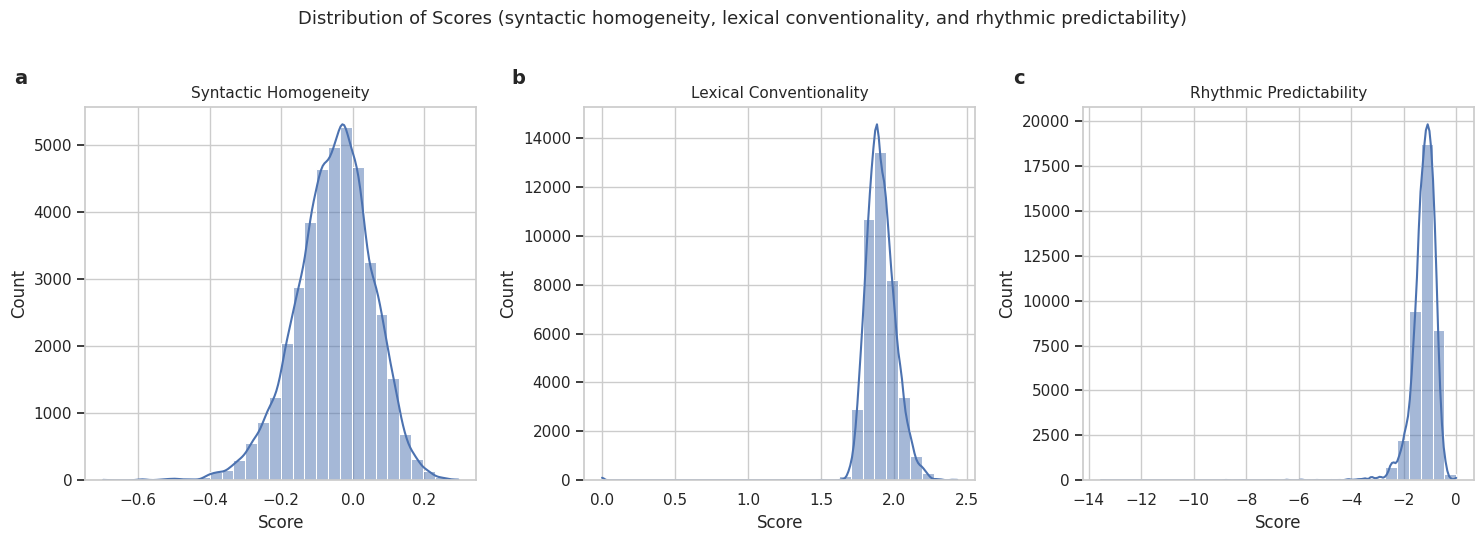

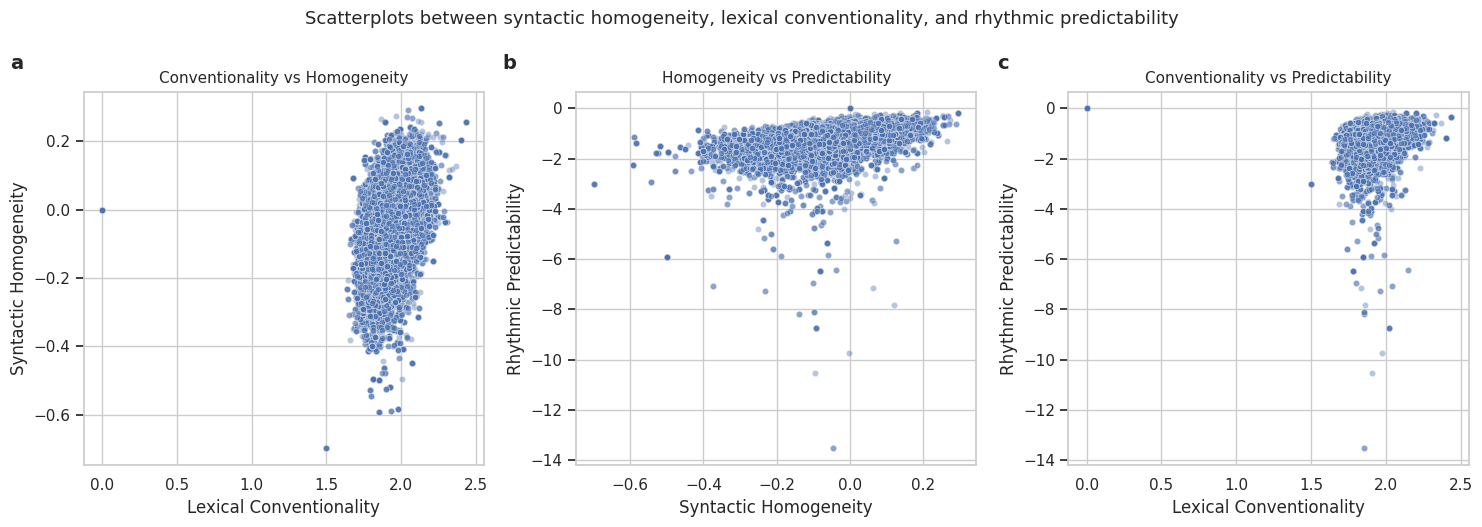

✅ All summary tables and figures saved in: /content/
📊 Individual plots saved in: /content/plots


In [ ]:
# @title 2. Descriptive analyses: coorealtion matrix, histograms, scatterplots
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---------------------------------
# Define output directories
# ---------------------------------
# Set a custom output directory for generated files and plots
custom_outdir = "/content/"
os.makedirs(custom_outdir, exist_ok=True)

# Create a subdirectory for plots within the custom output directory
plotdir = os.path.join(custom_outdir, "plots")
os.makedirs(plotdir, exist_ok=True)

# ---------------------------------
# Load scored data
# ---------------------------------
# Load the previously scored data from the CSV file
df = pd.read_csv("/content/drive/MyDrive/My study/Manuscript f1000/f1000/f1000_scored.csv")

# ---------------------------------
# Summary tables
# ---------------------------------
# Generate descriptive statistics for the scoring metrics
summary = df[["score_lrr", "score_fast_detectgpt", "score_imbd"]].describe().T
# Save the summary statistics to a CSV file
summary.to_csv(os.path.join(custom_outdir, "table_summary_scores.csv"), index=True)

# Correlation matrix (all scores + flags)
# Define columns for correlation analysis
corr_cols = [
    "score_lrr", "score_fast_detectgpt", "score_imbd",
    "flag_llm_lrr", "flag_llm_fdg", "flag_llm_imbd"
]
# Calculate the correlation matrix
corrs = df[corr_cols].corr()
# Save the correlation matrix to a CSV file
corrs.to_csv(os.path.join(custom_outdir, "table_correlations.csv"), index=True)

# Top examples for FDG and ImBD (qualitative exploration)
# Get the top 10 examples with the highest 'score_fast_detectgpt'
top_fdg = df.nlargest(10, "score_fast_detectgpt")[["title", "abstract", "score_fast_detectgpt"]]
# Get the top 10 examples with the highest 'score_imbd'
top_imbd = df.nlargest(10, "score_imbd")[["title", "abstract", "score_imbd"]]

# Save the top examples to CSV files
top_fdg.to_csv(os.path.join(custom_outdir, "table_topflag_fdg_examples.csv"), index=False)
top_imbd.to_csv(os.path.join(custom_outdir, "table_topflag_imbd_examples.csv"), index=False)

# ---------------------------------
# Graphical outputs
# ---------------------------------
# Set the seaborn style for plots
sns.set(style="whitegrid")

# === 1. Combined histogram panel for all three detectors ===
plt.figure(figsize=(15, 5))

# Define the score columns and their corresponding display labels
score_cols = [
    ("score_fast_detectgpt", "Syntactic Homogeneity"),
    ("score_lrr", "Lexical Conventionality"),
    ("score_imbd", "Rhythmic Predictability")
]

# Labels for each panel in the histogram figure
panel_labels = ["a", "b", "c"]

# Iterate through each score column to create a histogram subplot
for i, (col, label) in enumerate(score_cols, 1):
    ax = plt.subplot(1, 3, i)
    # Create a histogram with KDE (Kernel Density Estimate)
    sns.histplot(df[col].dropna(), kde=True, bins=30)

    # Add Panel Label (A, B, C) to each subplot
    # Note: x position moved to -0.15 to clear the new Y-axis labels
    ax.text(-0.15, 1.1, panel_labels[i-1], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')

    plt.title(label, fontsize=11)
    plt.xlabel("Score")

    # Explicitly set the Y-label and ensure ticks are visible for all panels
    plt.ylabel("Count")
    ax.tick_params(axis='y', left=True, labelleft=True)

plt.tight_layout()
# Add a super title for the entire figure
plt.suptitle("Distribution of Scores (syntactic homogeneity, lexical conventionality, and rhythmic predictability)",
             y=1.08, fontsize=13)

# Save the histogram figure
plt.savefig(os.path.join(plotdir, "panel_hist_scores.png"), dpi=300, bbox_inches="tight")
plt.show()

# === 2. Scatterplots between metrics ===
# Map internal column names to more descriptive labels for plots
name_map = {
    "score_lrr": "Lexical Conventionality",
    "score_fast_detectgpt": "Syntactic Homogeneity",
    "score_imbd": "Rhythmic Predictability"
}

# Define pairs of scores for scatter plots
scatter_pairs = [
    ("score_lrr", "score_fast_detectgpt", "Conventionality vs Homogeneity"),
    ("score_fast_detectgpt", "score_imbd", "Homogeneity vs Predictability"),
    ("score_lrr", "score_imbd", "Conventionality vs Predictability")
]

# Labels for each panel in the scatterplot figure
panel_labels = ["a", "b", "c"]

# Create the figure and a row of 3 axes for scatterplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Iterate through each pair to create a scatterplot subplot
for i, (xcol, ycol, label) in enumerate(scatter_pairs):
    ax = axes[i]

    # Create the scatter plot
    sns.scatterplot(data=df, x=xcol, y=ycol, alpha=0.4, s=20, ax=ax)

    # Add Panel Label (A, B, C) to each subplot
    ax.text(-0.15, 1.1, panel_labels[i], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')

    ax.set_title(label, fontsize=11)
    # Set x-axis label using the descriptive name map
    ax.set_xlabel(name_map[xcol])

    # Ensure every panel has its own Y label and ticks
    ax.set_ylabel(name_map[ycol])
    ax.tick_params(axis='y', which='both', left=True, labelleft=True)

# Final adjustments for layout
plt.tight_layout()
# Add a super title for the entire figure
plt.suptitle("Scatterplots between syntactic homogeneity, lexical conventionality, and rhythmic predictability",
             y=1.05, fontsize=13)

# Save the scatterplot panel
plt.savefig(os.path.join(plotdir, "panel_scatter_scores.png"), dpi=300, bbox_inches="tight")
plt.show()


# === 3. Yearly trend for all detectors ===
# Check if 'publication_year' column exists before plotting yearly trends
if "publication_year" in df.columns:
    # Group by publication year and calculate the mean of flag columns (proportion flagged)
    yearly = df.groupby("publication_year")[["flag_llm_fdg", "flag_llm_lrr", "flag_llm_imbd"]].mean().reset_index()
    plt.figure(figsize=(8, 5))
    # Plot trends for each flag
    plt.plot(yearly["publication_year"], yearly["flag_llm_fdg"], marker="o", label="Syntactic Homogeneity")
    plt.plot(yearly["publication_year"], yearly["flag_llm_lrr"], marker="o", label="Lexical Conventionality")
    plt.plot(yearly["publication_year"], yearly["flag_llm_imbd"], marker="o", label="Rhythmic Predictability")
    plt.title("Share of abstracts flagged for syntactic homogeneity, lexical conventionality, and rhythmic predictability")
    plt.xlabel("Publication year")
    plt.ylabel("Proportion flagged")
    plt.legend()
    plt.tight_layout()
    # Save the yearly trend plot
    plt.savefig(os.path.join(plotdir, "trend_flag_share_by_year_all.png"), dpi=300)
    plt.close()

# === 4. Boxplot by article type ===
# Check if 'article_type' column exists before plotting boxplots
if "article_type" in df.columns:
    plt.figure(figsize=(10, 6))
    # Create a boxplot of ImBD scores grouped by article type
    sns.boxplot(x="article_type", y="score_imbd", data=df)
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Article Type")
    plt.ylabel("Rhythmic Predictability")
    plt.title("Rhythmic Predictability by article type")
    plt.tight_layout()
    # Save the boxplot
    plt.savefig(os.path.join(plotdir, "boxplot_imbd_by_articletype.png"), dpi=300)
    plt.close()

print(f"✅ All summary tables and figures saved in: {custom_outdir}")
print(f"📊 Individual plots saved in: {plotdir}")

<>:80: SyntaxWarning: invalid escape sequence '\l'
<>:80: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-1106932244.py:80: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Syntactic Homogeneity, Lexical Conventionality, and Rhythmic Predictability: Raw vs. HP-Filtered Trend ($\lambda={LAMBDA}$)")


Plot saved to: /content/plots/combined_trend_all_detectors.png


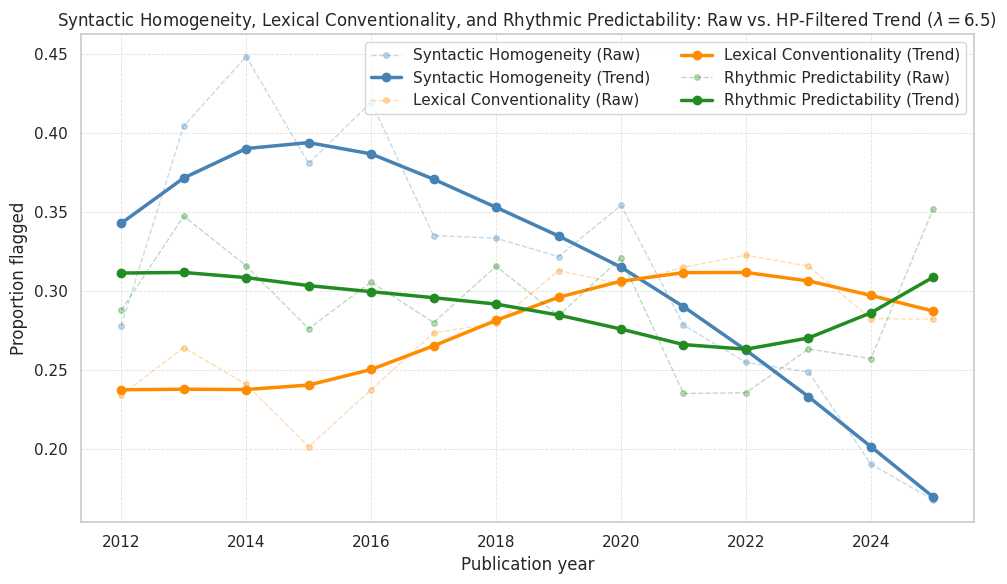

In [ ]:
# @title 3. Trend Analysis of the stylistic constructs: Raw vs HP-Filtered

# =====================================
# Combined Trend Analysis: Raw vs HP-Filtered
# =====================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from statsmodels.tsa.filters.hp_filter import hpfilter

# ---------------------------------
# 1. Setup & Directories
# ---------------------------------
# Define the custom output directory
custom_outdir = "/content/"
os.makedirs(custom_outdir, exist_ok=True)
# Define the plot directory within the custom output directory
plotdir = os.path.join(custom_outdir, "plots")
os.makedirs(plotdir, exist_ok=True)

# ---------------------------------
# 2. Load & Prepare Data
# ---------------------------------
# We start from the annual file generated by the scoring pipeline
file_path = '/content/plots/f1000_scores.csv'

# Check if the file exists before proceeding
if os.path.exists(file_path):
    df = pd.read_csv(file_path)

    # Define the columns corresponding to the flags and their descriptive names
    flag_cols = {
        'share_flag_fdg': 'Syntactic Homogeneity',
        'share_flag_lrr': 'Lexical Conventionality',
        'share_flag_imbd': 'Rhythmic Predictability'
    }

    # Set 'publication_year' as the index and select the flag columns
    annual_shares = df.set_index("publication_year")[list(flag_cols.keys())]

    # Rename columns for cleaner plotting labels using the defined map
    annual_shares = annual_shares.rename(columns=flag_cols)

    # ---------------------------------
    # 3. Apply HP Filter (Calculation Step)
    # ---------------------------------
    # Create a DataFrame to hold the smoothed (trend) components
    trends = pd.DataFrame(index=annual_shares.index)

    # Define the smoothing parameter (lambda) for annual data

    LAMBDA = 6.5

    # Apply the Hodrick-Prescott filter to each flag column
    for col in annual_shares.columns:
        # hpfilter returns (cycle, trend). We only want the trend component.
        cycle, trend_component = hpfilter(annual_shares[col], lamb=LAMBDA)
        trends[col] = trend_component

    # ---------------------------------
    # 4. Plotting (Combined)
    # ---------------------------------
    # Set the seaborn style for consistent plot aesthetics
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Define consistent colors for each metric
    colors = {
        "Syntactic Homogeneity": "steelblue",
        "Lexical Conventionality": "darkorange",
        "Rhythmic Predictability": "forestgreen"
    }

    # Plot both Raw (faded) and HP-Filtered (bold) trends
    for name, color in colors.items():
        # Plot Raw Data: Lower alpha, thinner dashed line, smaller marker
        plt.plot(annual_shares.index, annual_shares[name],
                 marker='o', markersize=4, linestyle='--', linewidth=1,
                 color=color, alpha=0.3, label=f"{name} (Raw)")

        # Plot HP Trend: Full alpha, thicker solid line, standard marker
        plt.plot(trends.index, trends[name],
                 marker='o', markersize=6, linewidth=2.5,
                 color=color, alpha=1.0, label=f"{name} (Trend)")

    # Set plot title, including the lambda value for the HP filter
    plt.title(f"Syntactic Homogeneity, Lexical Conventionality, and Rhythmic Predictability: Raw vs. HP-Filtered Trend ($\\lambda={LAMBDA}$)")
    plt.xlabel("Publication year")
    plt.ylabel("Proportion flagged")

    # Aesthetic touches
    plt.tight_layout()
    # Place legend in two columns to save vertical space
    plt.legend(ncol=2)
    # Add a grid for readability
    plt.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.6)

    # Save the plot to the specified directory
    save_path = os.path.join(plotdir, "combined_trend_all_detectors.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Plot saved to: {save_path}")

    plt.show()

else:
    # Handle case where the input file is not found
    print(f"Error: File not found at {file_path}")

<>:97: SyntaxWarning: invalid escape sequence '\l'
<>:97: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_5809/9055233.py:97: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Reviewer Recommendations: Raw vs. HP-Filtered Trend ($\lambda={LAMBDA}$)")


Plot saved to: /content/plots/combined_trend_reviewer_recommendations.png


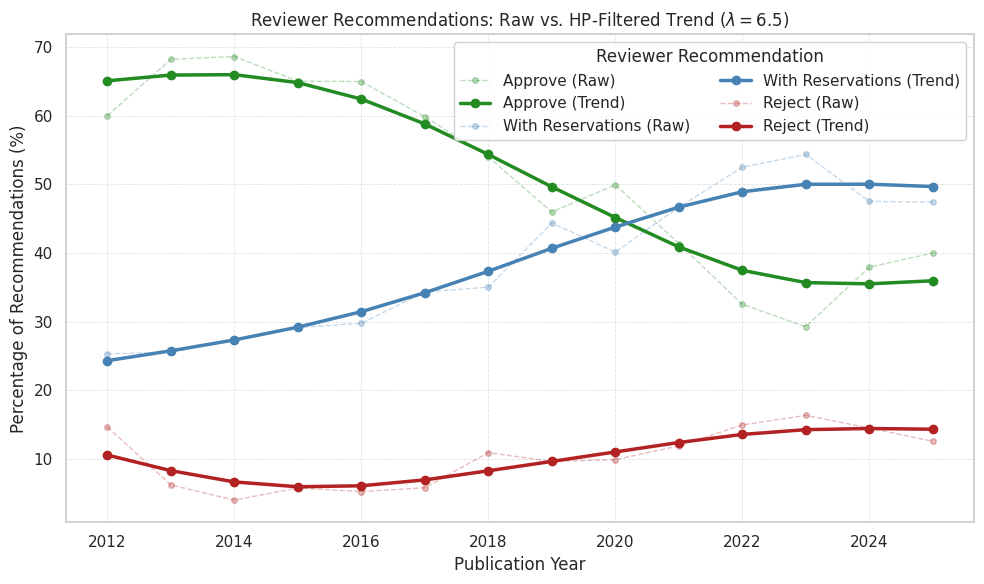

In [2]:
# @title 2. Trend Analysis of the reviewr recommendations: Raw vs HP-Filtered

# =====================================
# Combined Trend Analysis: Reviewer Recommendations
# Raw vs HP-Filtered
# =====================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from statsmodels.tsa.filters.hp_filter import hpfilter

# ---------------------------------
# 1. Setup & Directories
# ---------------------------------
# Define the custom output directory
custom_outdir = "/content/"
os.makedirs(custom_outdir, exist_ok=True)
# Define the plot directory within the custom output directory
plotdir = os.path.join(custom_outdir, "plots")
os.makedirs(plotdir, exist_ok=True)

# ---------------------------------
# 2. Load & Process Data
# ---------------------------------
# Specify the path to the scored unique abstracts file
file_path = '/content/f1000_unique_scored.csv'

# Check if the file exists before proceeding
if os.path.exists(file_path):
    df = pd.read_csv(file_path)

    # Drop rows where 'publication_year' or 'reviewer_recommendation' are missing
    df = df.dropna(subset=['publication_year', 'reviewer_recommendation'])

    # Group by year and recommendation type to count occurrences
    trend = df.groupby(['publication_year', 'reviewer_recommendation']).size().unstack(fill_value=0)

    # Convert counts to percentages of total recommendations per year (Raw Data)
    trend_percent = trend.div(trend.sum(axis=1), axis=0) * 100

    # Define a mapping for cleaner display names
    display_name_map = {
        "approve": "Approve",
        "approve-with-reservations": "With Reservations",
        "reject": "Reject"
    }
    # Rename columns for cleaner plotting labels
    trend_percent = trend_percent.rename(columns=display_name_map)

    # ---------------------------------
    # 3. Apply HP Filter (Calculation Step)
    # ---------------------------------
    # Create a DataFrame to store the smoothed trend components
    trend_smooth = pd.DataFrame(index=trend_percent.index)

    # Define the smoothing parameter (lambda) for annual data
    LAMBDA = 6.5

    # Apply the Hodrick-Prescott filter to each recommendation type column
    for col in trend_percent.columns:
        # hpfilter returns (cycle, trend). We extract the trend component.
        cycle, trend_component = hpfilter(trend_percent[col], lamb=LAMBDA)
        trend_smooth[col] = trend_component

    # ---------------------------------
    # 4. Plotting (Combined)
    # ---------------------------------
    # Set the seaborn style for consistent plot aesthetics
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Define semantic colors for different recommendation types using the new display names
    color_map = {
        "Approve": "forestgreen",
        "With Reservations": "steelblue",
        "Reject": "firebrick"
    }

    # Iterate through each recommendation type to plot its raw and smoothed trend
    for col in trend_percent.columns:
        # Get color from the map, or use a default if not found
        color = color_map.get(col, None)

        # Plot Raw Data: Lower alpha, thinner dashed line, smaller marker
        plt.plot(trend_percent.index, trend_percent[col],
                 marker='o', markersize=4, linestyle='--', linewidth=1,
                 color=color, alpha=0.3, label=f"{col} (Raw)")

        # Plot HP Trend: Full alpha, thicker solid line, standard marker
        plt.plot(trend_smooth.index, trend_smooth[col],
                 marker='o', markersize=6, linewidth=2.5,
                 color=color, alpha=1.0, label=f"{col} (Trend)")

    # Set plot title, including the lambda value for the HP filter
    plt.title(f"Reviewer Recommendations: Raw vs. HP-Filtered Trend ($\lambda={LAMBDA}$)")
    plt.xlabel("Publication Year")
    plt.ylabel("Percentage of Recommendations (%)")

    # Aesthetic touches
    plt.tight_layout()

    # Place the legend outside the plot area on the right, in a single column
    plt.legend(title='Reviewer Recommendation', ncol=2, framealpha=0.9)
    # Add a grid for readability
    plt.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.6)

    # Save the plot to the specified directory
    save_path = os.path.join(plotdir, "combined_trend_reviewer_recommendations.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Plot saved to: {save_path}")

    plt.show()

else:
    # Handle case where the input file is not found
    print(f"Error: File not found at {file_path}")